# Model Training and Testing

## Classifier Settings Overview

The **Classifier** tab is where you configure the learning block you chose to train your machine-learning model. In this case, we chose a **Classification** block, which will take input data and output a probability score for each class. This represents how confident the model is that the input is part of a particular class. 

Within the **Classifier** tab, you can select training settings and adjust the architecture of your neural network. The goal is to create a model that performs well on test data (new data it has not seen before).

This tutorial will cover how to choose training settings based on your dataset and the results of previous training sessions.

Note that changing one setting at a time is a good way to understand the effect that each setting has on your model. It is recommended to start with the default settings, then use the results to decide what to change.

### Number of Training Cycles

The first setting is the **number of training cycles** (also called epochs). This refers to the number of times the training algorithm will go through the full training dataset and update model parameters. More cycles give the model more time to learn patterns in the data, but too many cycles can cause **overfitting**. Overfitting is where the model "memorizes" the training data, and as a result, cannot generalize to new data it has never seen before. Essentially, the model performs well on training data but poorly on new test data. Overfitting can also occur when there is not enough training data or not enough diversity in the data.

In Edge Impulse, it is recommended to start with 50 training cycles and then to compare the **training accuracy** with **validation accuracy**. Both metrics can be found in the **training graphs** on the **EPOCH_ACCURACY** graph (the first one). 

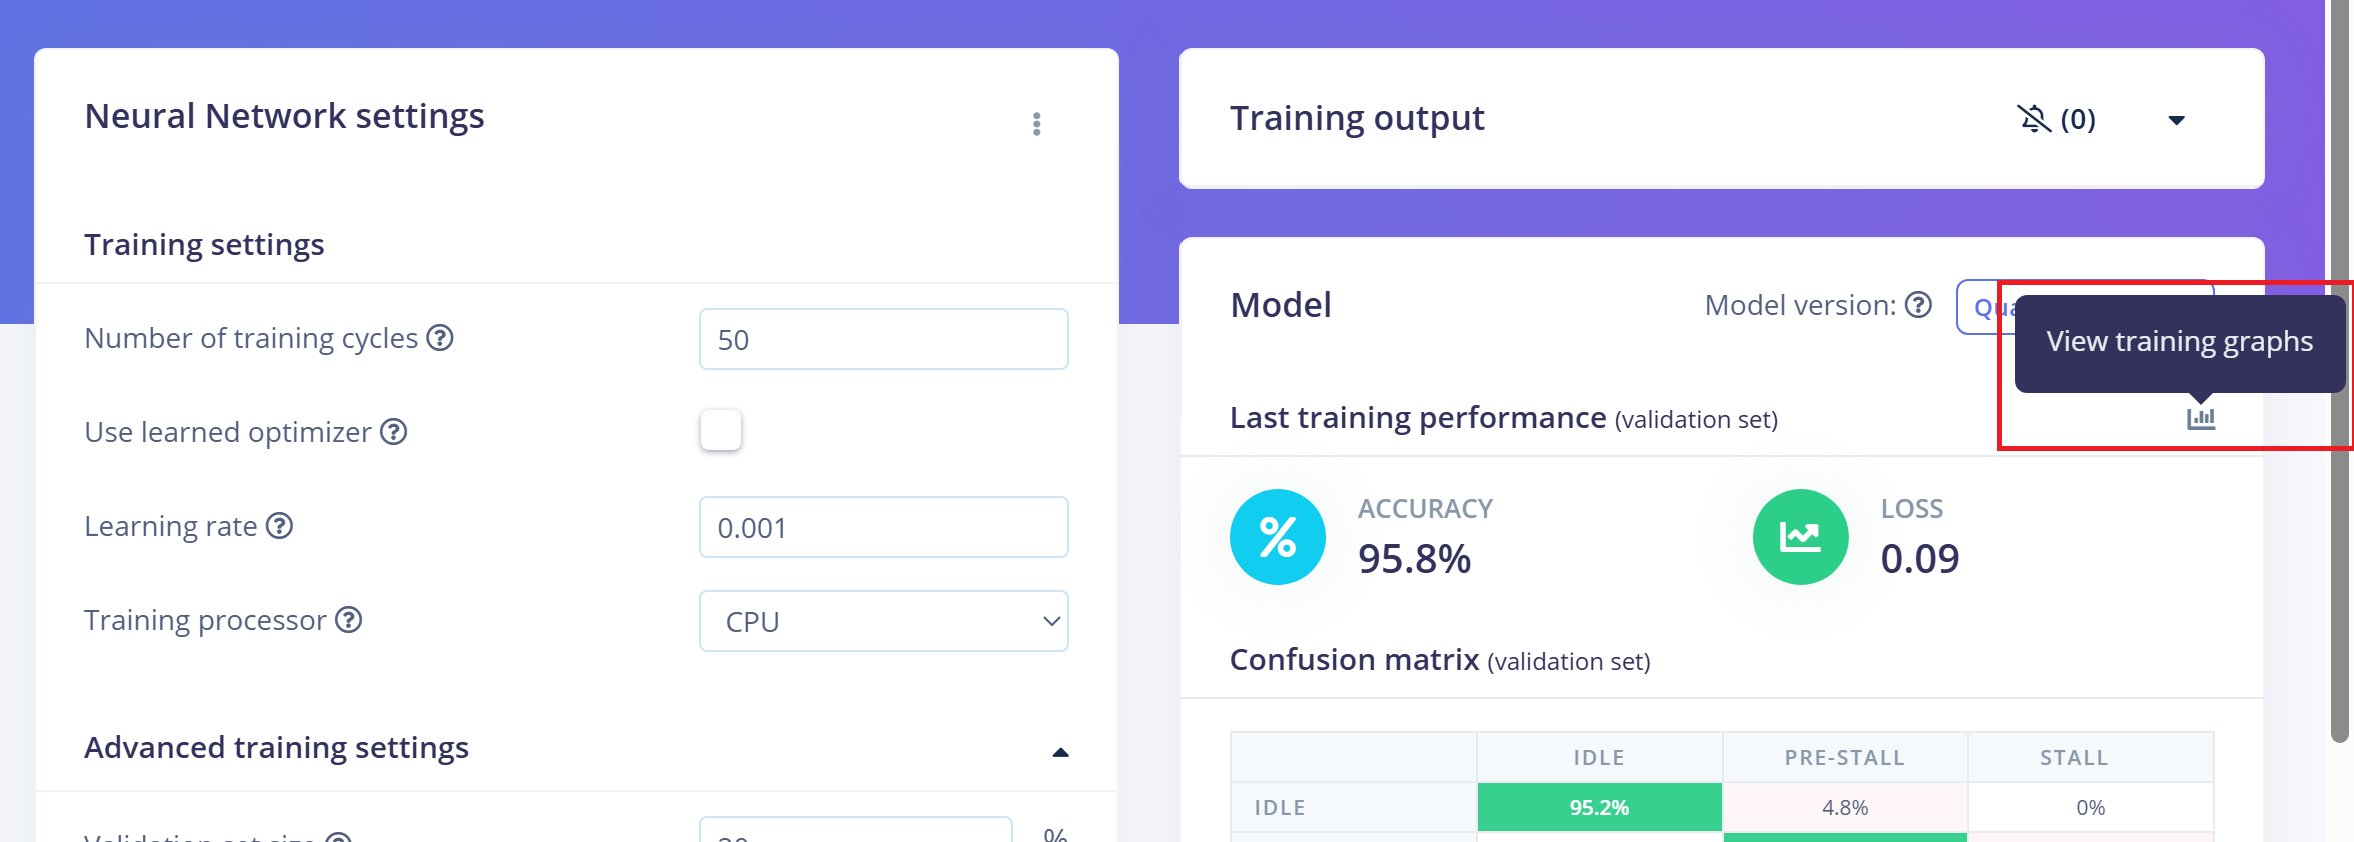


<img src = "Assets/Training_Graphs.png" width="60%" >

If both training and validation accuracy are low, the model may need more training cycles. However, if training accuracy continues to increase while validation accuracy stops improving or decreases, the model is likely overfitting and needs fewer cycles.

The **loss** is also a good way to check whether your model is overfitting. Both training and validation loss can be found in the second training graph. Ideally, both training and validation loss should decrease as the model trains. However, if training loss continues to decrease while validation loss stays constant or begins to increase, it is a sign that the model is overfitting.

After each training session, check the training graphs to decide whether the number of cycles should be adjusted.

### Use Learned Optimizer

This setting is useful when you are retraining a model and want to use optimizer information from previous training. For a new model, it is fine to leave this off.

### Learning Rate

The **learning rate** controls how much the model's internal weights are changed during each epoch. If the learning rate is too large, the model may make changes that are too large, causing the loss to jump around or stay stable. However, if the learning rate is too small, the model will only make small changes and may not learn enough in the number of training cycles you have selected.

### Training Processor

Edge Impulse recommends using the CPU for small datasets and the GPU for larger jobs. Our datasets are considered small, but if training is taking a long time, you can select the GPU to reduce training time.

### Validation Set Size

The validation set size determines how much of the training data will be set aside to test the model during training. 20% is a typical split.

### Split Train/Validation Set on Metadata Key

**This setting is not relevant to our data.** It is used to control how the training and validation data are split based on a metadata key. This is useful if your data is taken from multiple sources. 

For example, if you took data from 3 people and randomly split the data into training and validation data without a metadata key, it is possible that some data from Person 1 could end up in both the training and validation set. This means that the model will see very similar data from Person 1 during both training and validation. This can artificially increase the validation accuracy, making it look higher than it would be if the model was tested on data from a new person. Using a metadata key would keep related samples together when the algorithm creates the training and validation sets. 

### Batch Size

This setting determines how many samples the model will process in one training cycle before updating its parameters. If batch size is not set, Edge Impulse will use the default value (32). Note that training can fail if the batch size is too high.

### Auto-Weight Classes

This is useful when your classes are unbalanced (some classes contain more samples than others). 

When classes are unbalanced, it can cause the model to pay more attention to classes with more samples (overfit). The best way to solve this problem is by collecting a well-rounded dataset with a reasonable number of samples for each class. However, by auto-weighting the classes, we can stop the model from overfitting by giving more weight to classes with fewer samples.

### Profile int8 Model

This is useful if you plan to deploy your model on an embedded device (such as a microcontroller). An int8 model uses 8-bit integer values, which can reduce the amount of memory required by the model.

This setting will allow you to see information about how the 8-bit model will perform.

### Neural Network Architecture

At the bottom, under **neural network architecture**, you will see several layers each consisting of a number of neurons. All of the neurons in a higher layer are connected to the neurons in the next layer. The weight of the connection between two neurons is randomly assigned at the beginning of training. Then, the neural network is given training data, and its output is compared to the correct answers. Based on the results, the weights of the connections between neurons are adjusted, and the process is repeated for the number of training cycles you have chosen. Remember that the goal is for the neural network to adjust its weights so that it can make accurate predictions on both the training data and test data that it has not seen before. 

<img src = "Assets/NN_Architecture.png" width="40%" >

The architecture of the neural network can affect how well the model learns. A model that is too simple may not be able to learn the patterns in your data, but a model that is too complex (too many neurons) is more likely to overfit.

In Edge Impulse, you can add more layers to your model by clicking on **Add extra layer**. Each layer type has a description, which you can use to decide what layers to add. 

In this workshop, since we have already used spectral analysis to extract features from the data, it is recommended to only use **Dense** layers in the neural network architecture. This is because Dense layers can take a 1D set of extracted features as input and produce a 1D set of outputs that can be passed directly to another Dense layer. Meanwhile, layers such as 1D convolutional layers are designed for time-series data and require the input to have multiple dimensions. Their output data will also include multiple dimensions which must be flattened before being passed to a Dense layer. 

## Training Tips
- Start with the default settings, train your model, then look at both the training and validation accuracy and loss.
    - If both accuracies are low, the model may need more training cycles or a more complex architecture.
    - If training accuracy is much higher than validation accuracy, the model may be overfitting, so try reducing the number of training cycles or simplifying the network.
- When tuning your model, change one setting at a time and use the results (training graphs and confusion matrix) to decide which adjustments to make.

### Confusion Matrix

The **Confusion Matrix** is a 3x3 matrix located under the **Results** section of both the Classifier and Model Testing tabs. It can be used to see which classes the model is getting right and which classes it is confusing with others. The rows of the confusion matrix represent the actual class of each sample, while the columns represent the class predicted by the model. Each cell contains the number of samples that fall into that combination of actual and predicted classes. Ideally, most samples should be along the diagonal. Values that appear outside the diagonal are incorrect classifications made by the model.

<img src = "Assets/Confusion_Matrix.png" width="50%" >

## Retraining Model Tab

The **retrain model** tab is for retraining an existing model while keeping the existing impulse and classifier setup the same. This feature is useful when you have added new training data but do not need to regenerate the features.

If you are changing the classifier settings, you must **Save & Train** in the **Classifier** tab.

<img src = "Assets/Retrain_Tab.png" width="50%" >

## Testing Your Model

Before you test your model, you must make sure that it has been fully trained. Then, navigate to the **model testing** tab, and click **classify all**. Once the model has classified all of the data in your testing set, you can see its testing accuracy, the feature explorer, and the confusion matrix. The testing accuracy is what we will be assessing in the competition on Day 3.

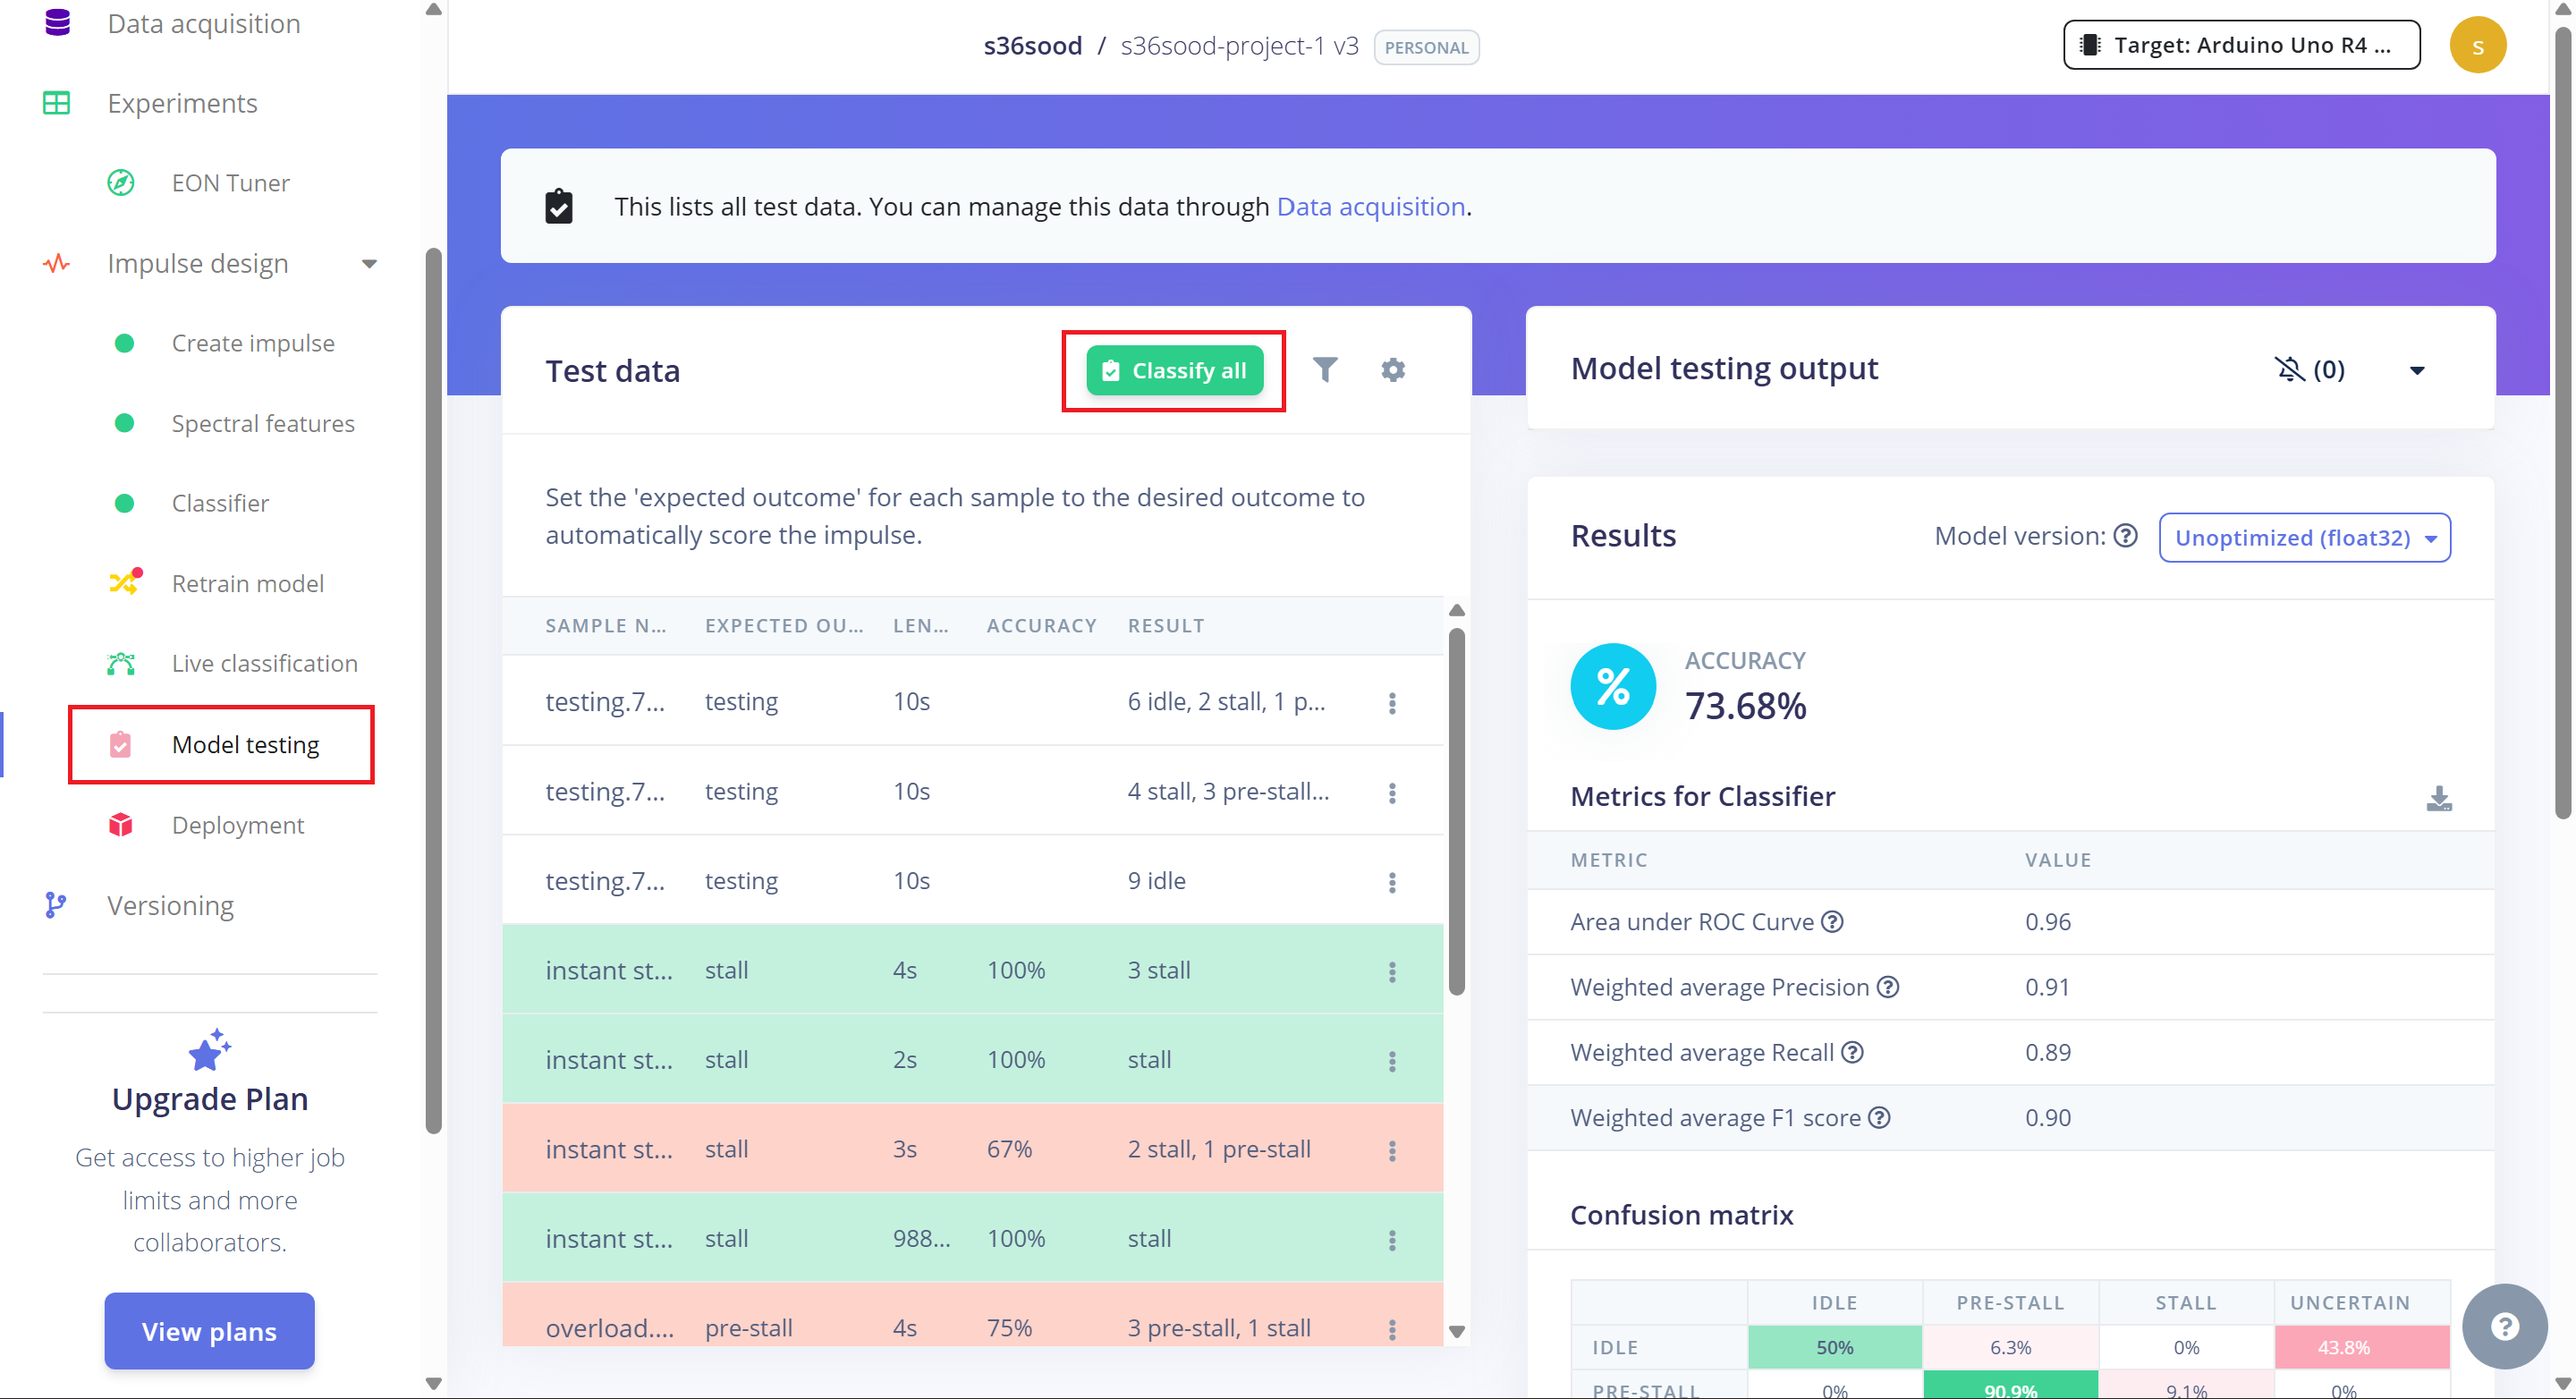

## Live Classification

If you would like to test your model against real-time data, you can go to the **Live Classification** tab. Here, you can use the data forwarder to collect an unclean sample for the model to analyze. Your model will divide the sample into windows of the size which you set in your impulse, and classify each window. You can drag the sliding window on the graph or scroll through the table to see all of the classifications. 

![\IdeasClinicUWaterloo\Robotics_Workshop\Day 2\Assets\Live_Classification.png](<attachment:\IdeasClinicUWaterloo\Robotics_Workshop\Day 2\Assets\Live_Classification.png>)

![\IdeasClinicUWaterloo\Robotics_Workshop\Day 2\Assets\Live_Classification_Result.png](<attachment:\IdeasClinicUWaterloo\Robotics_Workshop\Day 2\Assets\Live_Classification_Result.png>)
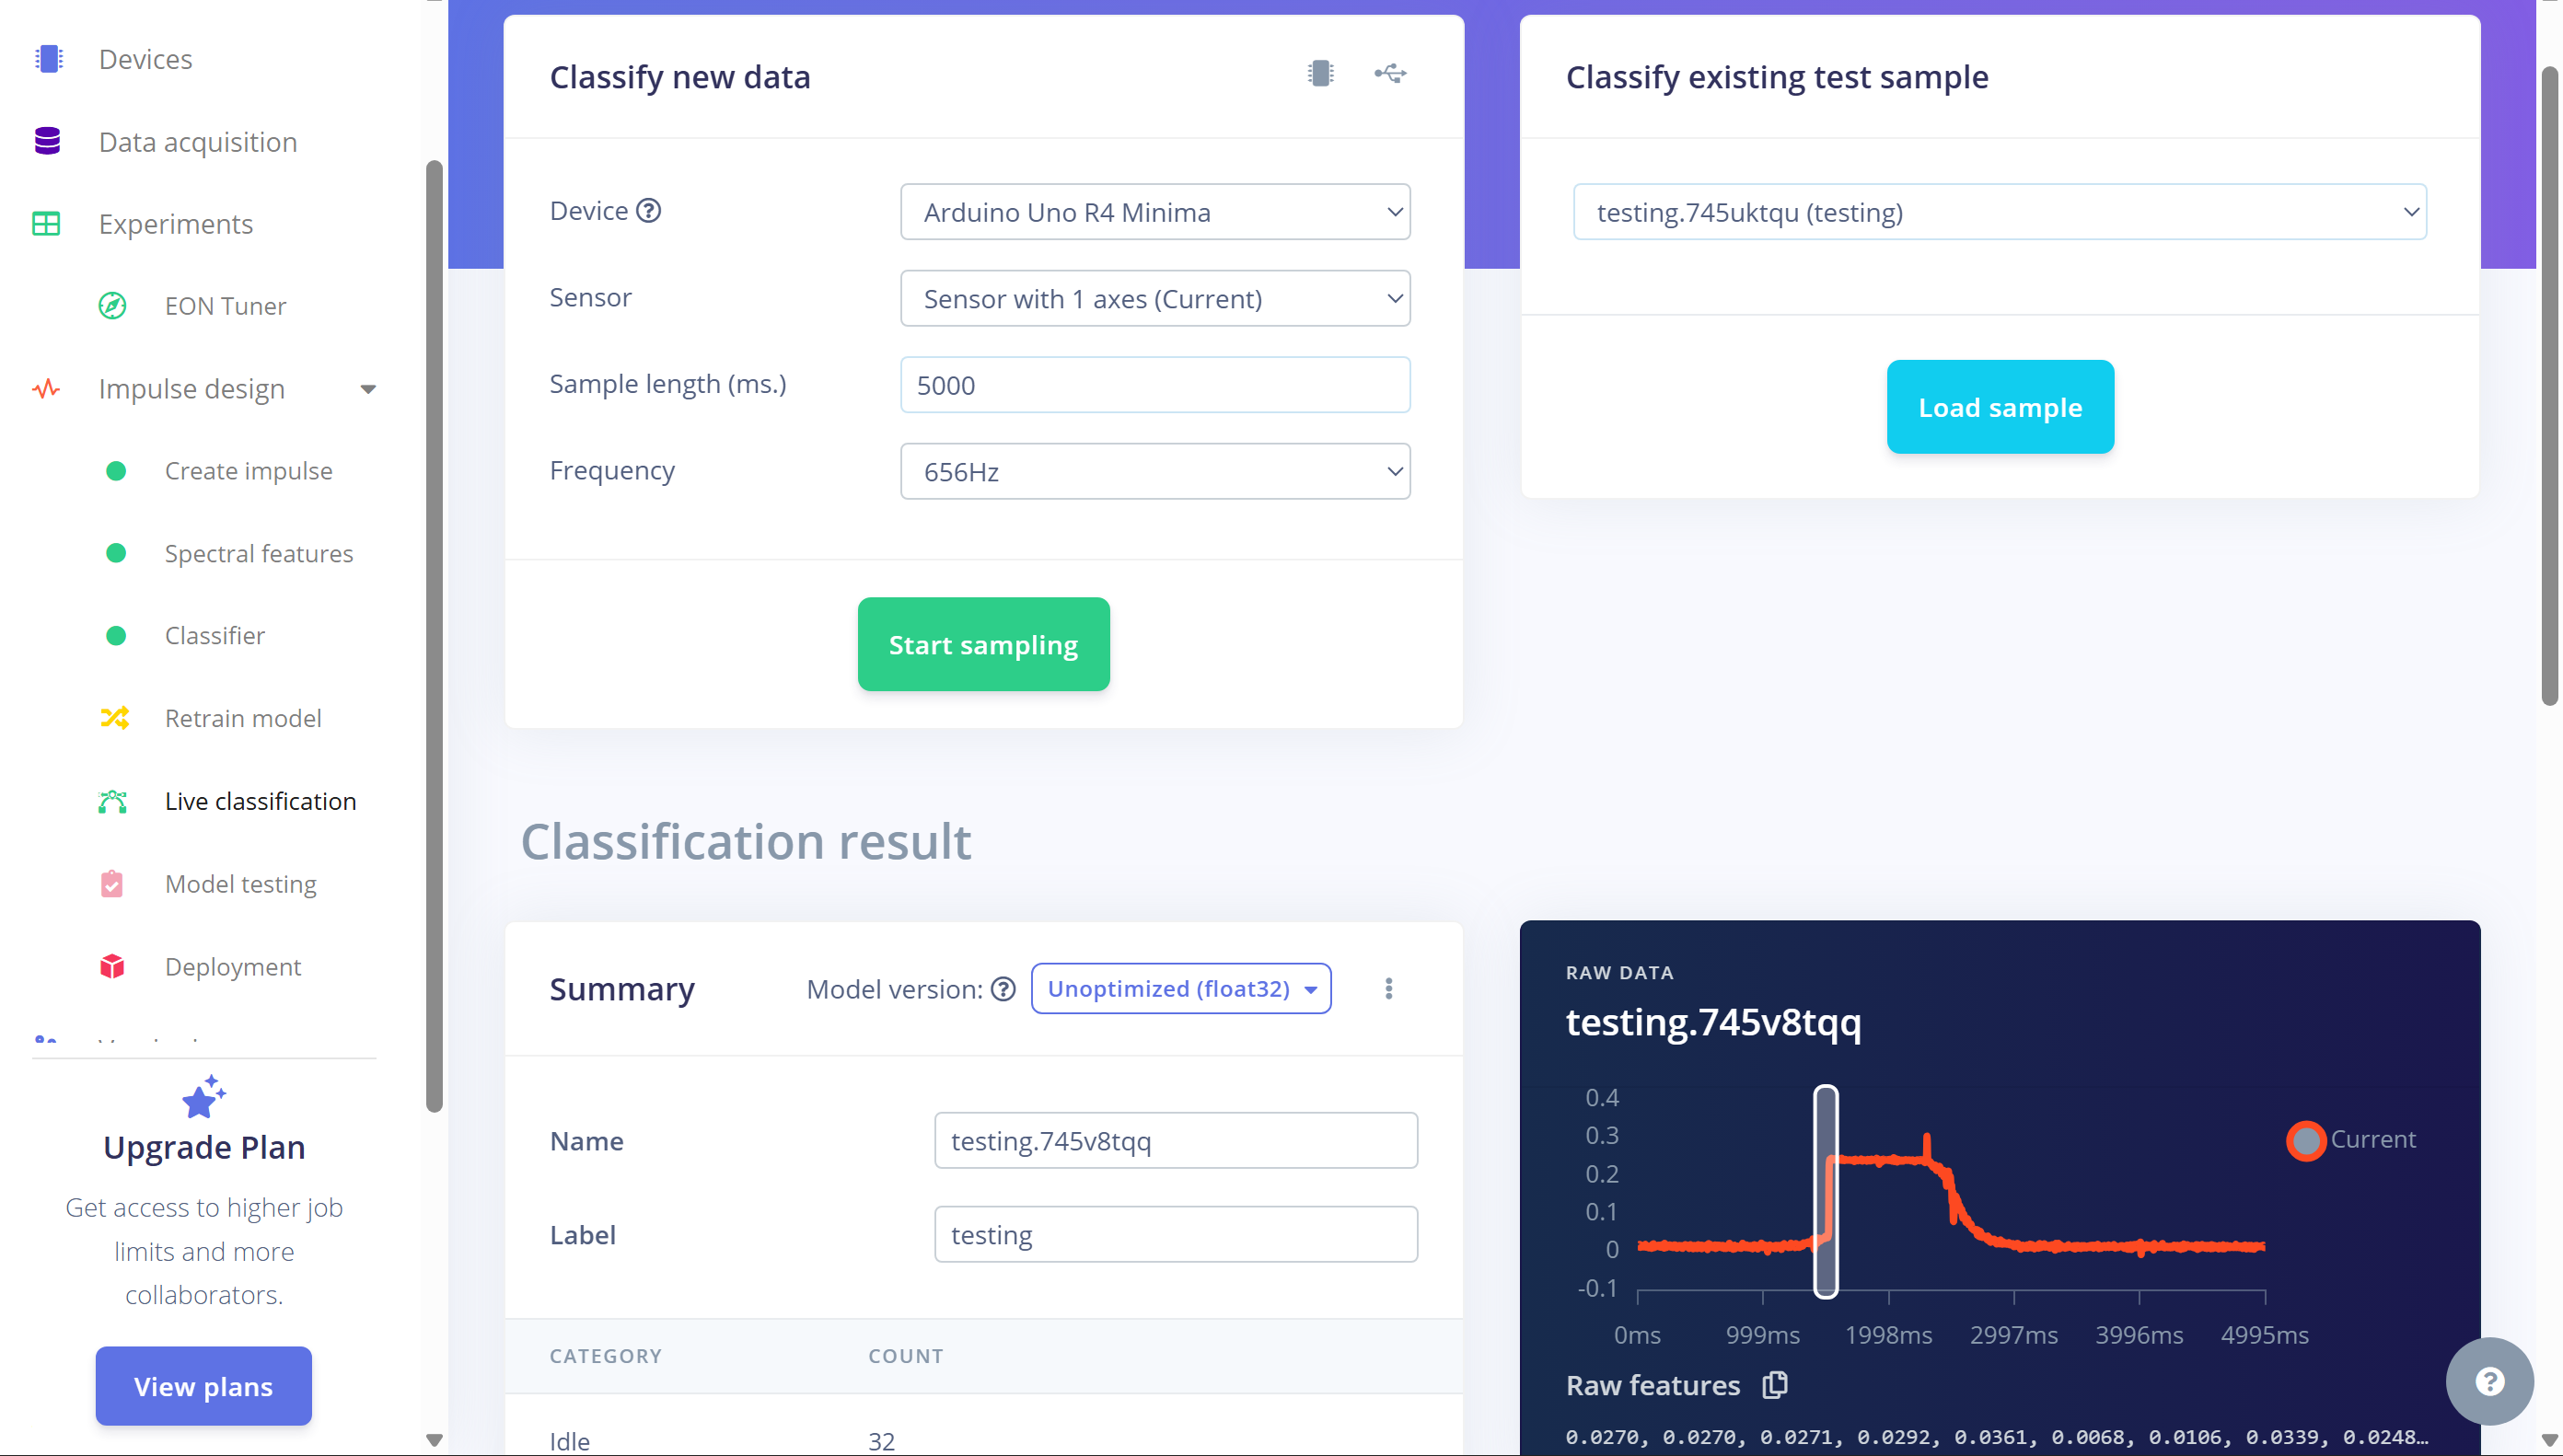
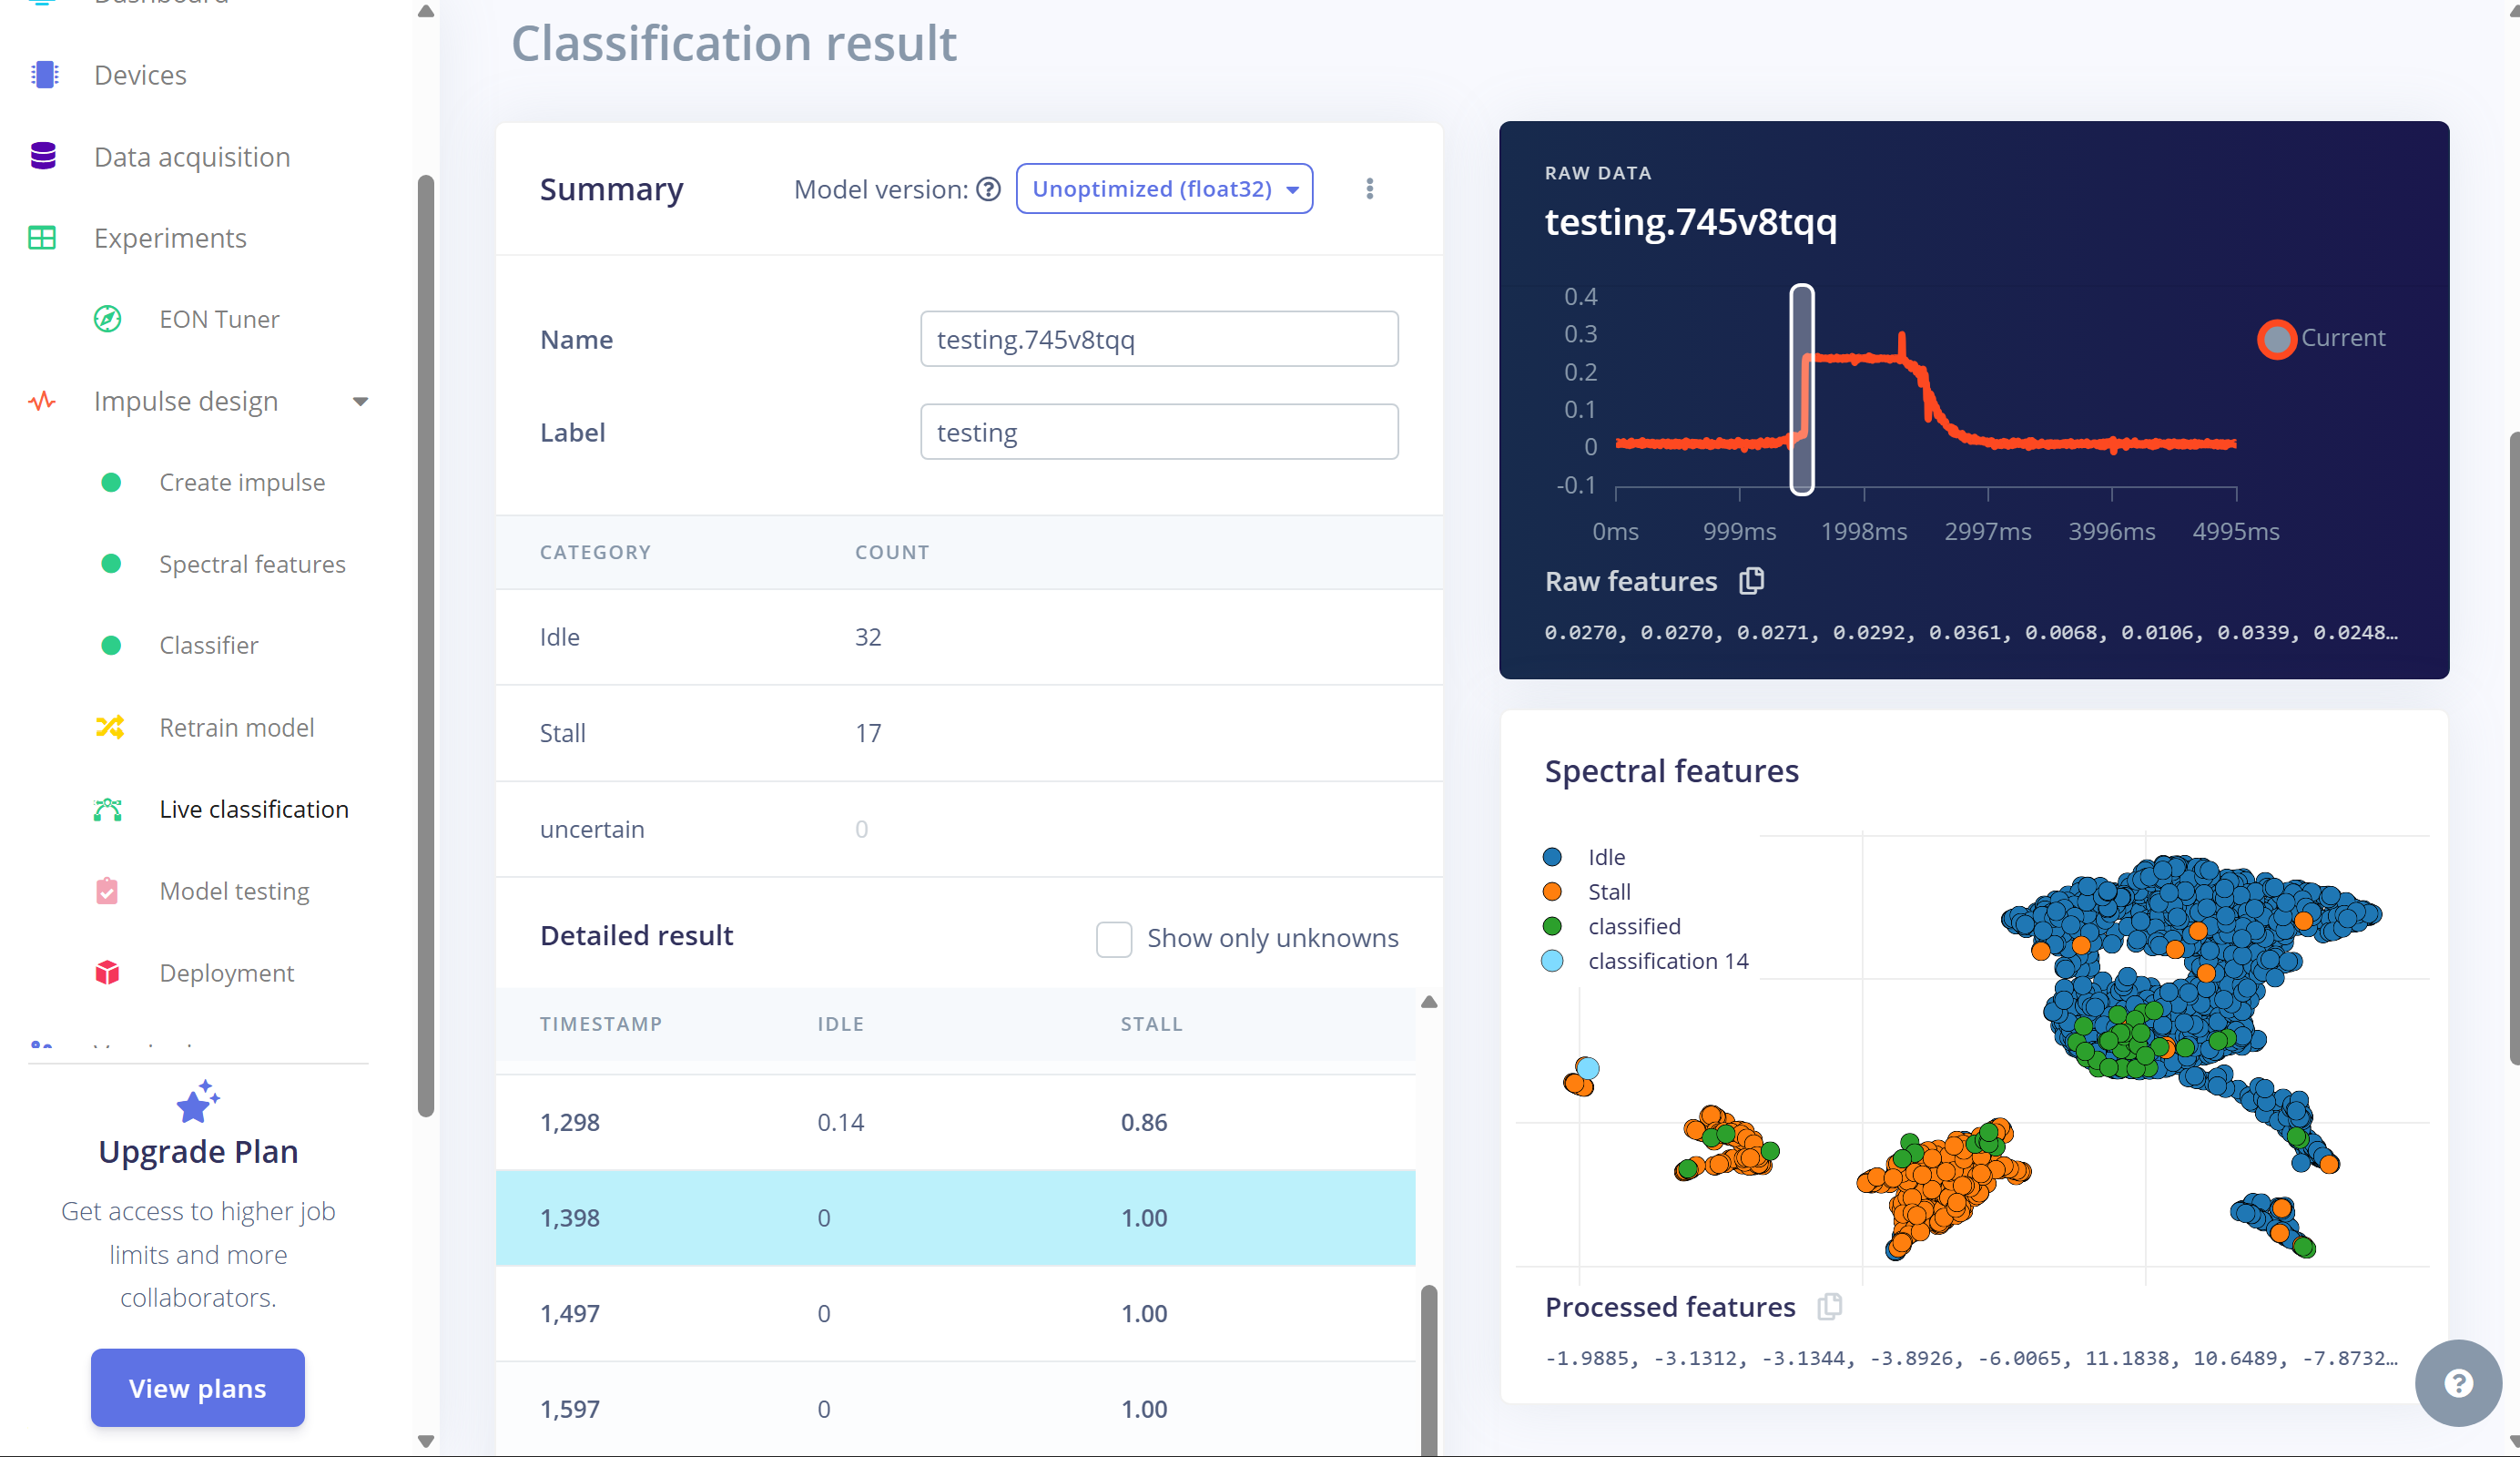

## Summary:

Raw Data $\rightarrow$ Processing Block (DSP) $\rightarrow$ Features $\rightarrow$ Learning Block (ML) $\rightarrow$ Prediction